In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from src.utils.config import *

In [137]:
# Cargamos el dataset
df = pd.read_csv(RAW_DIR  / 'dataset_final.csv')
df.head()

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,alertable,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification
0,--PJHxphWEs.wav,gun_shot,['gun_shot'],gun_shot,['gun_shot'],sonidos\gunshot\--PJHxphWEs.wav,audioset,train,indefinida,True,True,True,wav,10.008,44100.0,Stereo,16.0,1411200.0,1724.11,2026-05-12 17:56:50
1,--aE2O5G5WE.wav,gun_shot,['gun_shot'],gun_shot,['gun_shot'],sonidos\gunshot\--aE2O5G5WE.wav,audioset,train,indefinida,True,True,True,wav,10.008,44100.0,Stereo,16.0,1411200.0,1724.08,2026-05-12 12:27:49
2,-0DLPzsiXXE.wav,ambient_noise,['ambient_noise'],ambient_noise,['ambient_noise'],sonidos\music\-0DLPzsiXXE.wav,audioset,train,indefinida,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 17:57:08
3,-0SdAVK79lg.wav,ambient_noise,['ambient_noise'],ambient_noise,['ambient_noise'],sonidos\music\-0SdAVK79lg.wav,audioset,train,indefinida,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 12:36:58
4,-11LhdJgBb8.wav,ambient_noise,['ambient_noise'],ambient_noise,['ambient_noise'],sonidos\music\-11LhdJgBb8.wav,audioset,train,indefinida,False,False,True,wav,19.994,48000.0,Stereo,16.0,1536000.0,3748.86,2026-05-12 17:57:22


In [138]:
#imprimimos el numero de filas
print(f"Numero De Filas en 'df': {len(df)}")

# Verificamos La Cantidad De Variables Por Tipos De Datos en df que son los datos que vamos a aplicar el EDA:
pd.Series.value_counts(df.dtypes)

Numero De Filas en 'df': 128844


str        12
float64     5
bool        3
Name: count, dtype: int64

In [139]:
#Obtenemos que columnas tienen valores nulos y porcentage respectivamente
print("------------------PORCENTAJE DE VALORES NULOS DEL df---------------------\n")
info_nulls = pd.DataFrame({
    '% Nullidad': df.isna().sum() / len(df) * 100
}).sort_values(by='% Nullidad', ascending = False)
info_nulls

------------------PORCENTAJE DE VALORES NULOS DEL df---------------------



,% Nullidad
labels,44.098289
human_labels,44.098289
bit_velocity,0.007761
bit_depth,0.007761
date_modification,0.000776
audio_format,0.000776
sample_rate,0.000776
size,0.000776
duration,0.000776
channels,0.000776


In [140]:
df[df["size"].isna()]

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,alertable,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification
117941,synthetic_001_1.00_4.40.wav,/C/crying_300aeae2,"[""/C/crying_300aeae2""]",crying,"[""crying""]",/home/andres/Documentos/proyecto4geeks/data/ra...,VOICe,train,indefinida,True,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [141]:
df = df[df["size"].notna()]
df[df["size"].isna()]

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,alertable,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification


In [142]:
#imprimimos el numero de filas
print(f"Numero De Filas en 'df': {len(df)}")

# Verificamos La Cantidad De Variables Por Tipos De Datos en df que son los datos que vamos a aplicar el EDA:
pd.Series.value_counts(df.dtypes)

Numero De Filas en 'df': 128843


str        12
float64     5
bool        3
Name: count, dtype: int64

In [143]:

# =========================
# CONFIG
# =========================

# Lista de columnas a analizar
def history_plot(df,columns_to_plot):

    # Número máximo de valores únicos a mostrar
    top_n = 40

    # =========================
    # GRAFICOS
    # =========================

    # Crear figura dinámica
    fig, axes = plt.subplots(
        nrows=len(columns_to_plot),
        figsize=(12, 5 * len(columns_to_plot))
    )

    # Si solo hay una columna
    if len(columns_to_plot) == 1:
        axes = [axes]

    # Recorrer columnas
    for ax, col in zip(axes, columns_to_plot):

        # Conteo de valores únicos
        value_counts = (
            df[col]
            .astype(str)
            .value_counts()
            .head(top_n)
        )

        # Gráfico de barras
        ax.bar(
            value_counts.index,
            value_counts.values
        )

        ax.set_title(f"Valores únicos - {col}")
        ax.set_xlabel("Valor")
        ax.set_ylabel("Frecuencia")

        # Rotar labels
        ax.tick_params(axis='x', rotation=45)

    # Ajustar layout
    plt.tight_layout()

    # Mostrar
    plt.show()

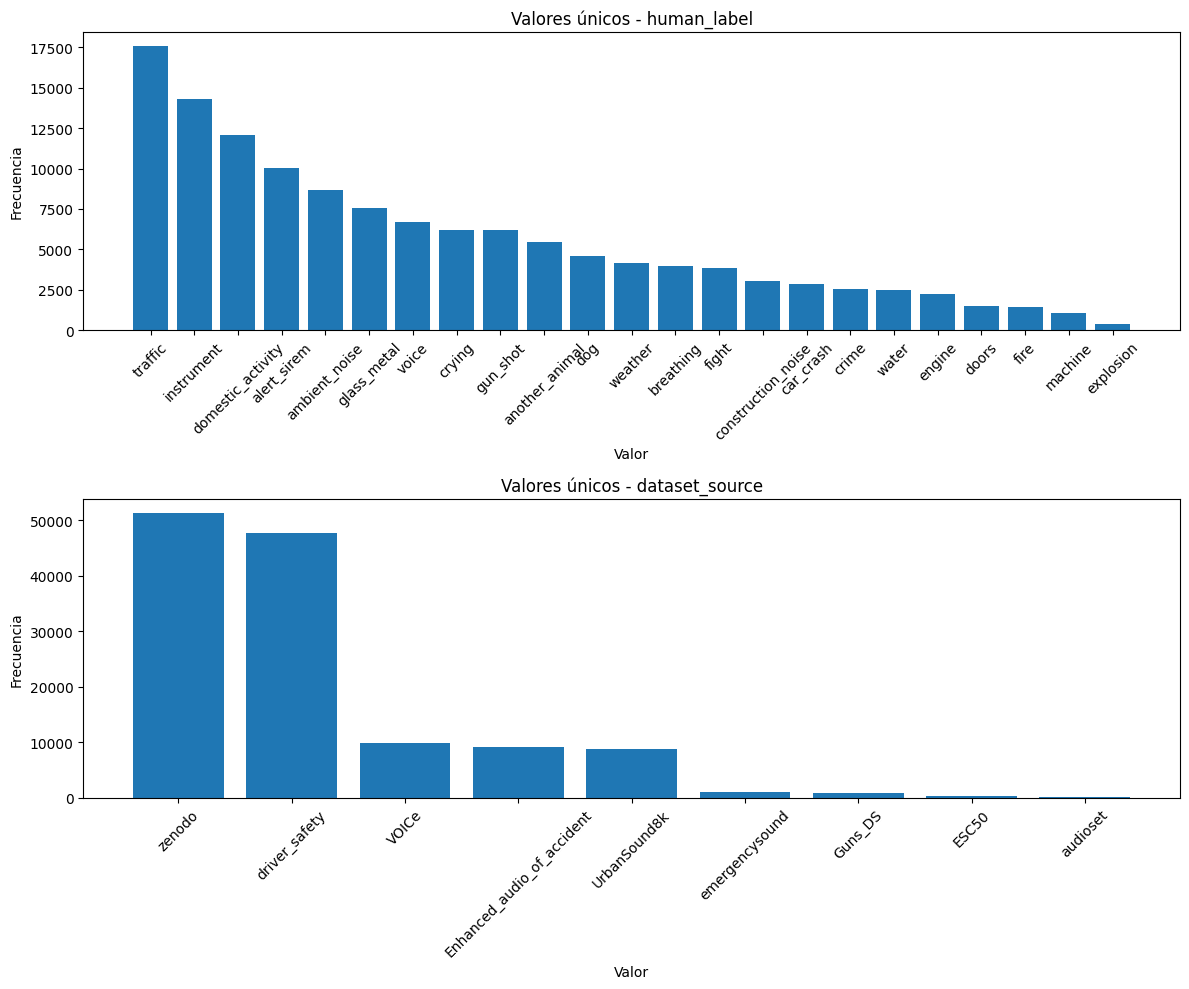

In [144]:
columns_to_plot = [
    "human_label",
    "dataset_source"
]
history_plot(df,columns_to_plot)

In [145]:

df["human_label"].value_counts()

human_label
traffic               17581
instrument            14283
domestic_activity     12052
alert_sirem           10023
ambient_noise          8663
glass_metal            7540
voice                  6662
crying                 6219
gun_shot               6214
another_animal         5444
dog                    4600
weather                4168
breathing              3969
fight                  3867
construction_noise     3038
car_crash              2870
crime                  2550
water                  2513
engine                 2217
doors                  1474
fire                   1409
machine                1087
explosion               400
Name: count, dtype: int64

In [146]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
import numpy as np

# ============================
# 1. SEPARAR TRAIN / TEST
# ============================

train_df = df[df['split'] == 'train'].copy()
test_df = df[df['split'] == 'test'].copy()

indices = np.arange(len(train_df)).reshape(-1, 1)
y_train = train_df['human_label'].values

# ============================
# 2. DISTRIBUCIÓN REAL
# ============================

dist = train_df['human_label'].value_counts()

# ============================
# 3. CONFIGURACIÓN DESEADA
# ============================

undersample_target = {
    'traffic': 9000,
    'instrument': 9000,
    'domestic_activity': 9000,
    'alert_sirem': 9000,
    'ambient_noise': 8600,   # corregido automáticamente
}

oversample_target = {
    'explosion': 3000,
    'machine': 3000,
    'fire': 3000,
    'doors': 3000,
    'engine': 3500,
    'water': 3500,
    'crime': 3500,
    'car_crash': 3500,
    'construction_noise': 3500,
    'fight': 4000,
    'breathing': 4000,
}

# ============================
# 4. AJUSTE AUTOMÁTICO
# ============================

# Evitar pedir más muestras de las que existen (undersampling)
for cls, target in undersample_target.items():
    max_allowed = dist[cls]
    if target > max_allowed:
        undersample_target[cls] = max_allowed
        print(f"⚠️ Ajustado undersample {cls}: {target} → {max_allowed}")

# Oversampling no necesita ajuste (puede crear copias)

# ============================
# 5. UNDERSAMPLING
# ============================

under = RandomUnderSampler(
    sampling_strategy=undersample_target,
    random_state=42
)

indices_under, y_under = under.fit_resample(indices, y_train)
indices_under = indices_under.flatten().astype(int)

# ============================
# 6. OVERSAMPLING
# ============================

over = RandomOverSampler(
    sampling_strategy=oversample_target,
    random_state=42
)

indices_final, y_final = over.fit_resample(
    indices_under.reshape(-1, 1),
    y_under
)
indices_final = indices_final.flatten().astype(int)

print(f"\n✅ Resampling completado:")
print(f"   Original: {len(train_df)} → Final: {len(indices_final)}")
print(f"   Distribución final:\n{pd.Series(y_final).value_counts().sort_index()}\n")

# ============================
# 7. RECONSTRUIR DATAFRAME
# ============================

train_resampled = train_df.iloc[indices_final].reset_index(drop=True)
train_resampled['split'] = 'train'

test_resampled = test_df.copy()

df_final = pd.concat([train_resampled, test_resampled], ignore_index=True)

print(f"📊 DataFrame final:")
print(f"   Shape: {df_final.shape}")
print(f"   Train: {(df_final['split'] == 'train').sum()}")
print(f"   Test: {(df_final['split'] == 'test').sum()}\n")

# ============================
# 8. GUARDAR
# ============================

df_final.to_csv(RAW_DIR / 'dataset_final_resampled.csv', index=False)
print(f"\n💾 Guardado en: dataset_final_resampled.csv")


⚠️ Ajustado undersample alert_sirem: 9000 → 8677
⚠️ Ajustado undersample ambient_noise: 8600 → 7199

✅ Resampling completado:
   Original: 106996 → Final: 113397
   Distribución final:
alert_sirem           8677
ambient_noise         7199
another_animal        4570
breathing             4000
car_crash             3500
construction_noise    3500
crime                 3500
crying                5182
dog                   3935
domestic_activity     9000
doors                 3000
engine                3500
explosion             3000
fight                 4000
fire                  3000
glass_metal           5917
gun_shot              4983
instrument            9000
machine               3000
traffic               9000
voice                 4977
water                 3500
weather               3457
Name: count, dtype: int64

📊 DataFrame final:
   Shape: (135244, 20)
   Train: 113397
   Test: 21847


💾 Guardado en: dataset_final_resampled.csv


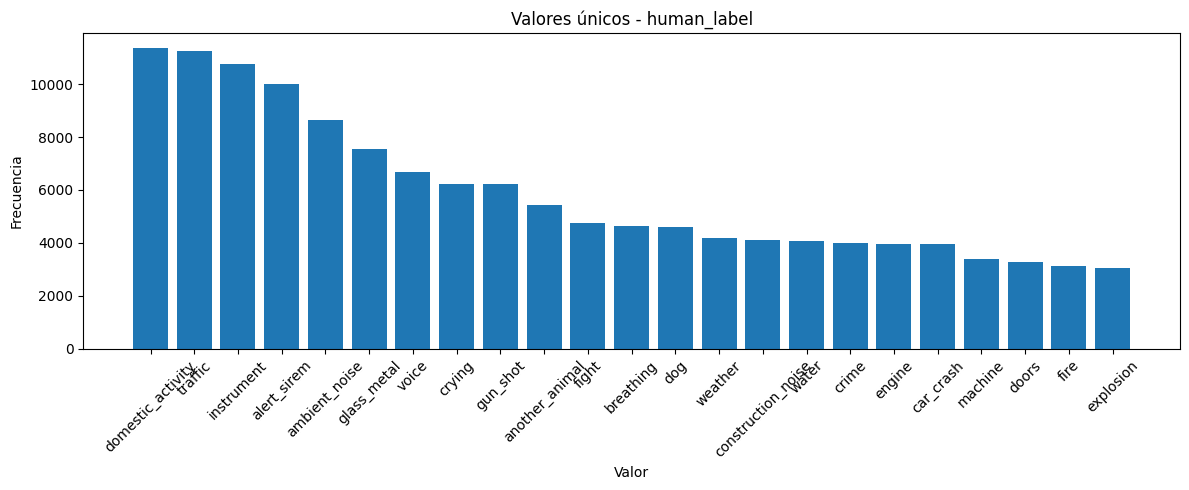

In [147]:
columns_to_plot = [
    "human_label",
]
history_plot(df_final,columns_to_plot)